In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA       # 차원 축소, compose: 구성, 결합하다.

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, confusion_matrix      # 이와 같이 정답이 없는 비지도학습의 평가는 주로 silhouette_score를 이용


## 데이터 로드 및 EDA

- Sensed_WFuel, Sensed_Core_Speed, Sensed_T3, Sensed_Ps3, Sensed_T45, Sensed_T5 에서 결측치 발생
- 각 컬럼의 평균값 분석

In [4]:
data = pd.read_csv("./data/training_data.csv")
data_val = pd.read_csv("./data/val/val_0.csv")
data_test = pd.read_csv("./data/test/test_0.csv")

data.info(), data.isnull().sum(), data_val, data['ESN'].unique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59702 entries, 0 to 59701
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ESN                 59702 non-null  int64  
 1   Cycles_Since_New    59702 non-null  int64  
 2   Snapshot            59702 non-null  int64  
 3   Cumulative_WWs      59702 non-null  int64  
 4   Cumulative_HPC_SVs  59702 non-null  int64  
 5   Cumulative_HPT_SVs  59702 non-null  int64  
 6   Sensed_Altitude     59702 non-null  float64
 7   Sensed_Mach         59702 non-null  float64
 8   Sensed_Pamb         59702 non-null  float64
 9   Sensed_Pt2          59702 non-null  float64
 10  Sensed_TAT          59702 non-null  float64
 11  Sensed_WFuel        59005 non-null  float64
 12  Sensed_VAFN         59702 non-null  float64
 13  Sensed_VBV          59702 non-null  float64
 14  Sensed_Fan_Speed    59702 non-null  float64
 15  Sensed_Core_Speed   59005 non-null  float64
 16  Sens

(None,
 ESN                     0
 Cycles_Since_New        0
 Snapshot                0
 Cumulative_WWs          0
 Cumulative_HPC_SVs      0
 Cumulative_HPT_SVs      0
 Sensed_Altitude         0
 Sensed_Mach             0
 Sensed_Pamb             0
 Sensed_Pt2              0
 Sensed_TAT              0
 Sensed_WFuel          697
 Sensed_VAFN             0
 Sensed_VBV              0
 Sensed_Fan_Speed        0
 Sensed_Core_Speed     697
 Sensed_T25              0
 Sensed_T3              60
 Sensed_Ps3             60
 Sensed_T45            757
 Sensed_P25              0
 Sensed_T5             757
 Cycles_to_WW            0
 Cycles_to_HPC_SV        0
 Cycles_to_HPT_SV        0
 dtype: int64,
       ESN  Cycles  Snapshot  Sensed_Altitude  Sensed_Mach  Sensed_Pamb  \
 0     107       0         1       220.101374     0.101318    14.636435   
 1     107       0         2       258.101374     0.230594    14.617612   
 2     107       0         3      2095.101374     0.290444    13.707636   
 3 

In [5]:
data.describe()

,ESN,Cycles_Since_New,Snapshot,Cumulative_WWs,Cumulative_HPC_SVs,Cumulative_HPT_SVs,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,...,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45,Sensed_P25,Sensed_T5,Cycles_to_WW,Cycles_to_HPC_SV,Cycles_to_HPT_SV
count,59702.000000,59702.000000,59702.000000,59702.000000,59702.00000,59702.000000,59702.000000,59702.000000,59702.000000,59702.000000,...,59005.000000,59702.000000,59642.000000,59642.000000,58945.000000,59702.000000,58945.000000,59702.000000,59702.000000,59702.000000
mean,102.506616,10001.039161,4.463737,9.563214,0.73902,2.236608,16675.581885,0.495905,8.566961,9.883362,...,20093.693162,925.594075,1449.093725,296.418376,2024.943775,25.112427,1287.186998,492.033098,3814.086965,1681.456065
std,1.117289,5775.813291,2.368842,5.822830,0.73094,1.740880,12283.169365,0.230523,4.252336,3.646641,...,1504.384274,9794.159991,372.203912,120.223325,432.712110,161.848251,434.287400,291.762176,2458.531937,1072.865457
min,101.000000,0.000000,1.000000,0.000000,0.00000,0.000000,-489.554524,0.000849,3.443702,4.553797,...,0.000000,-2379.012207,588.017684,7.226304,0.538878,-19003.917865,0.537815,0.000000,0.000000,0.000000
25%,102.000000,5000.000000,2.000000,4.000000,0.00000,1.000000,1282.321516,0.233281,4.585174,6.503256,...,19606.487278,660.054910,1385.020642,197.250469,1925.741058,19.216999,1198.737498,240.000000,1660.000000,770.000000
50%,103.000000,10000.000000,4.000000,10.000000,1.00000,2.000000,20772.321516,0.623214,6.538017,8.450916,...,20076.631907,687.643710,1447.016033,255.908097,2011.468433,24.513918,1260.492942,490.000000,3580.000000,1590.000000
75%,104.000000,15010.000000,7.000000,15.000000,1.00000,4.000000,28983.280264,0.677312,14.012064,14.327764,...,20607.271153,716.626388,1517.773196,432.348902,2110.232844,39.637221,1358.055793,740.000000,5790.000000,2480.000000
max,104.000000,20000.000000,8.000000,20.000000,2.00000,6.000000,35019.554225,0.746895,14.952901,15.509660,...,235762.778358,895556.308785,27943.085337,525.844996,27811.130622,45.877380,27675.035363,1160.000000,9530.000000,4790.000000


## 데이터 전처리 및 스케일 보정
- 결측치 총 개수: 757
- 이는 전체 데이터에서 약 1.26%
- 따라서, 이 결측치는 제거

In [6]:
df = data.copy()
df.dropna(inplace=True)
df.isnull().sum()

ESN                   0
Cycles_Since_New      0
Snapshot              0
Cumulative_WWs        0
Cumulative_HPC_SVs    0
Cumulative_HPT_SVs    0
Sensed_Altitude       0
Sensed_Mach           0
Sensed_Pamb           0
Sensed_Pt2            0
Sensed_TAT            0
Sensed_WFuel          0
Sensed_VAFN           0
Sensed_VBV            0
Sensed_Fan_Speed      0
Sensed_Core_Speed     0
Sensed_T25            0
Sensed_T3             0
Sensed_Ps3            0
Sensed_T45            0
Sensed_P25            0
Sensed_T5             0
Cycles_to_WW          0
Cycles_to_HPC_SV      0
Cycles_to_HPT_SV      0
dtype: int64

In [7]:
# 59702 - 58945 = 757, 총 757개의 결측 데이터 삭제
df.describe(), df.shape, df.columns

(                ESN  Cycles_Since_New      Snapshot  Cumulative_WWs  \
 count  58945.000000      58945.000000  58945.000000    58945.000000   
 mean     102.489422      10000.977182      4.464687        9.560387   
 std        1.112403       5778.479791      2.369621        5.824881   
 min      101.000000          0.000000      1.000000        0.000000   
 25%      102.000000       5000.000000      2.000000        4.000000   
 50%      102.000000      10000.000000      4.000000       10.000000   
 75%      103.000000      15000.000000      7.000000       15.000000   
 max      104.000000      20000.000000      8.000000       20.000000   
 
        Cumulative_HPC_SVs  Cumulative_HPT_SVs  Sensed_Altitude   Sensed_Mach  \
 count        58945.000000        58945.000000     58945.000000  58945.000000   
 mean             0.740521            2.236169     16674.706636      0.495967   
 std              0.731984            1.740879     12287.277151      0.230339   
 min              0.000000

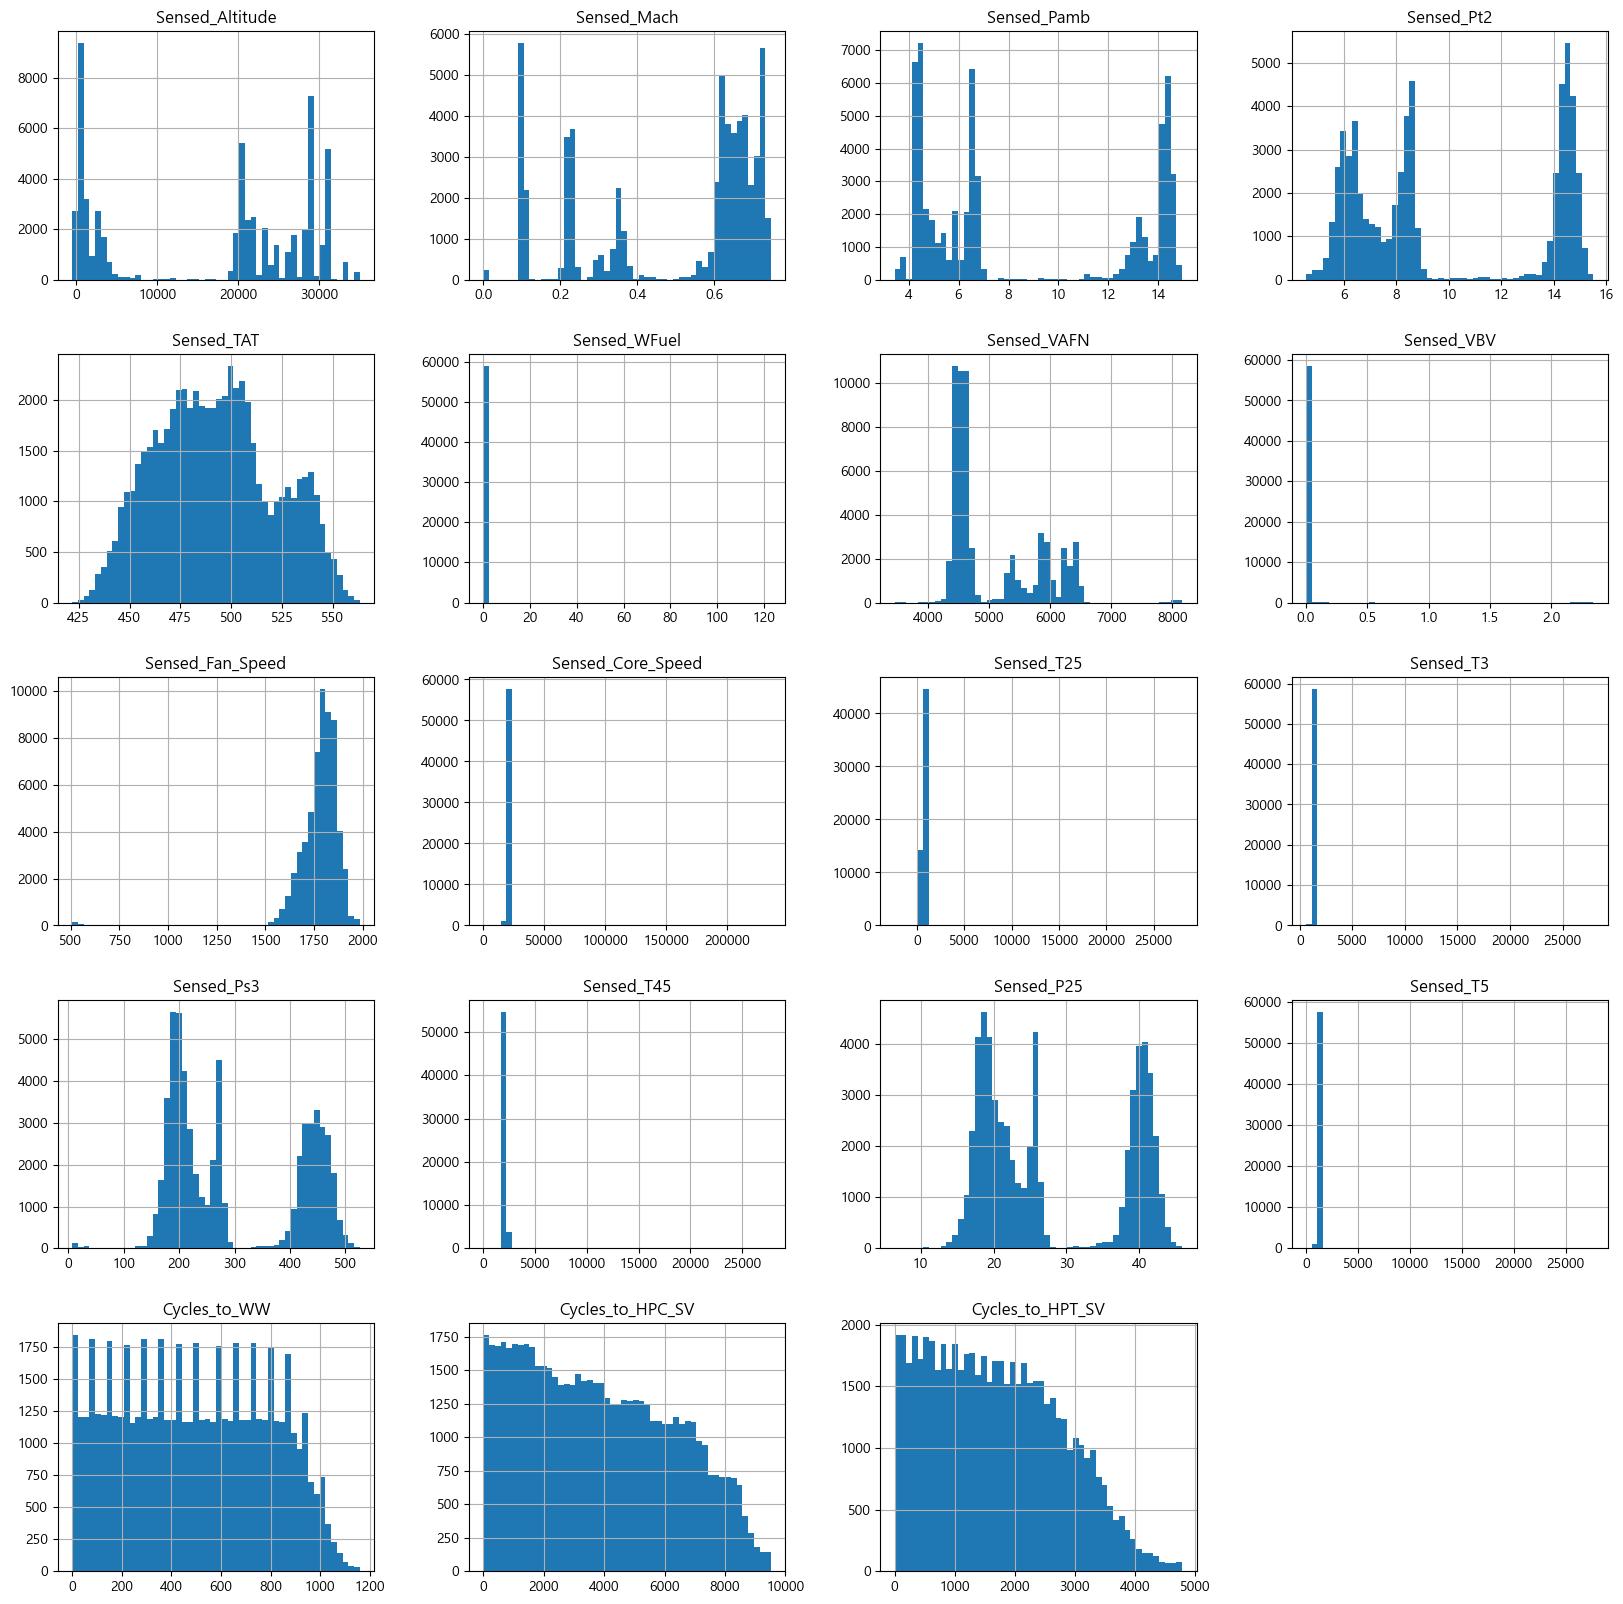

In [8]:
df[['Sensed_Altitude',
        'Sensed_Mach', 'Sensed_Pamb', 'Sensed_Pt2', 'Sensed_TAT',
        'Sensed_WFuel', 'Sensed_VAFN', 'Sensed_VBV', 'Sensed_Fan_Speed',
        'Sensed_Core_Speed', 'Sensed_T25', 'Sensed_T3', 'Sensed_Ps3',
        'Sensed_T45', 'Sensed_P25', 'Sensed_T5', 'Cycles_to_WW',
        'Cycles_to_HPC_SV', 'Cycles_to_HPT_SV']].hist(bins=50, figsize=(20,20), grid=True)

plt.show()

In [9]:
## 각 그래프에서 척도의 범위가 비정상적으로 넓은 그래프를 찾고, 그 데이터를 기반으로 클러스터링 진행

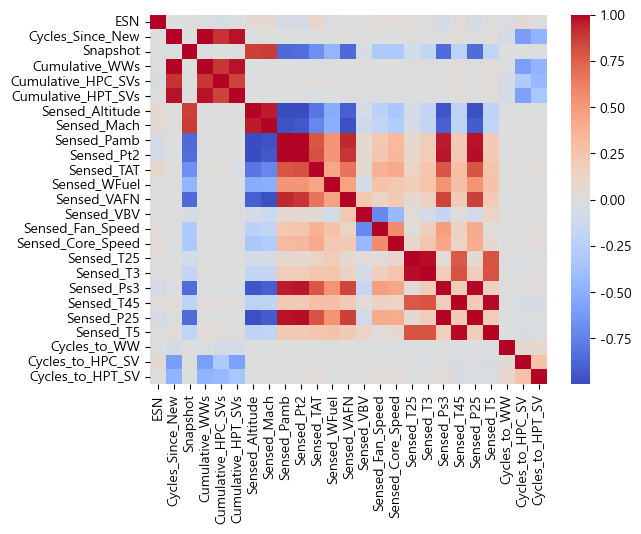

<Figure size 2000x2000 with 0 Axes>

In [10]:
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm')
plt.figure(figsize=(20, 20))
plt.show()

In [11]:
## 변수 스케일링

In [12]:
X = df[['Sensed_WFuel', 'Sensed_Pamb', 'Sensed_VAFN','Sensed_Pt2','Sensed_VBV','Sensed_Fan_Speed', 'Sensed_TAT',
    'Sensed_Core_Speed', 'Sensed_T25']]
features_names = X.columns.tolist()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X, X_scaled

(       Sensed_WFuel  Sensed_Pamb  Sensed_VAFN  Sensed_Pt2  Sensed_VBV  \
 0          1.211455    14.250475  6228.393355   14.289459         0.0   
 1          1.231128    14.224853  5859.340344   14.628042         0.0   
 2          1.095966    12.989563  5350.679994   14.055733         0.0   
 3          0.685568     6.679796  4608.368473    8.621275         0.0   
 4          0.623099     6.230955  4553.016846    8.183755         0.0   
 ...             ...          ...          ...         ...         ...   
 59697      0.715083     6.589584  4654.172715    8.512299         0.0   
 59698      0.502384     4.561522  4641.629244    5.978532         0.0   
 59699      0.502604     4.559792  4637.807993    5.988464         0.0   
 59700      0.527744     4.561738  4535.065483    6.414373         0.0   
 59701      0.528386     4.559575  4533.445019    6.423547         0.0   
 
        Sensed_Fan_Speed  Sensed_TAT  Sensed_Core_Speed  Sensed_T25  
 0           1900.287778  535.406306    

In [13]:
## 최적 k 찾기 (Elbow 기법)

In [14]:
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans_temp = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10       # k-means를 여러 번 실행하되, 매번 초기 중심점(seed)을 다르게 설정하여 실행하는 횟수
    )
    kmeans_temp.fit(X_scaled)
    labels = kmeans_temp.predict(X_scaled)

    silhouettes.append({
        "K": k,
        "Score": silhouette_score(X_scaled, labels)
    })
    inertias.append({
        "K": k,
        "Inertia": kmeans_temp.inertia_
    })

inertias_df = pd.DataFrame(inertias)
inertias_df

,K,Inertia
0,2,313737.111452
1,3,213428.756942
2,4,162095.175134
3,5,122509.787366
4,6,101401.573165
5,7,81783.023487
6,8,67599.958545
7,9,55703.525927
8,10,47419.617946


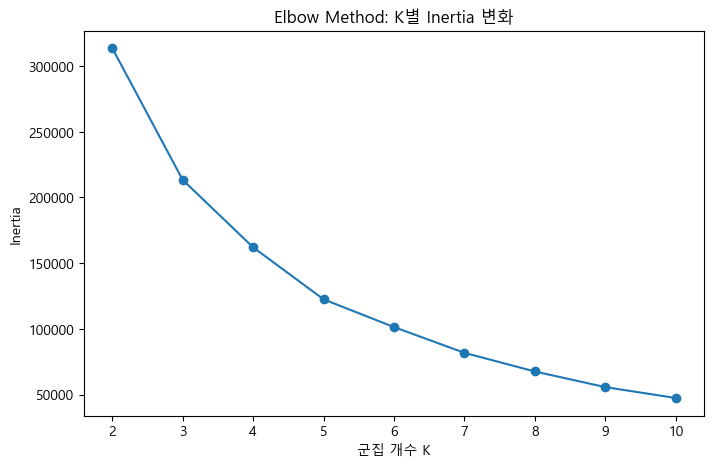

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(inertias_df["K"], inertias_df["Inertia"], marker="o")
plt.xlabel("군집 개수 K")
plt.ylabel("Inertia")
plt.title("Elbow Method: K별 Inertia 변화")
plt.xticks(list(K_range))
plt.show()

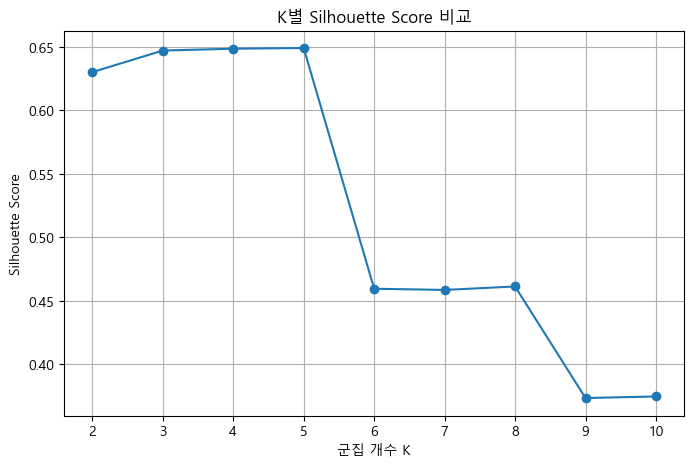

In [16]:
silhouette_df = pd.DataFrame(silhouettes)

plt.figure(figsize=(8, 5))

plt.plot(
    silhouette_df["K"],
    silhouette_df["Score"],
    marker="o"
)

plt.xlabel("군집 개수 K")
plt.ylabel("Silhouette Score")
plt.title("K별 Silhouette Score 비교")
plt.xticks(silhouette_df["K"])
plt.grid(True)
plt.show()

In [17]:
## 최적 K값을 기준으로 클러스터링

In [18]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    # init="auto"
)

X['Cluster'] = kmeans_final.fit_predict(X_scaled)

features_names = ['Sensed_WFuel', 'Sensed_Pamb', 'Sensed_VAFN','Sensed_Pt2','Sensed_VBV','Sensed_Fan_Speed', 'Sensed_TAT', 'Sensed_Core_Speed', 'Sensed_T25']
centroids = kmeans_final.cluster_centers_
centroids_origin = scaler.inverse_transform(centroids)
centroid_df = pd.DataFrame(centroids_origin, columns=features_names)
# centroid_df = pd.DataFrame(centroids, columns=features_names)

# X
# X['Cluster'].value_counts()
centroid_df.describe()

C:\Users\cyj01\AppData\Local\Temp\ipykernel_11504\3056213632.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Cluster'] = kmeans_final.fit_predict(X_scaled)


,Sensed_WFuel,Sensed_Pamb,Sensed_VAFN,Sensed_Pt2,Sensed_VBV,Sensed_Fan_Speed,Sensed_TAT,Sensed_Core_Speed,Sensed_T25
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.338927,9.153459,5511.346541,10.423704,0.426358,1531.790270,500.765992,17567.775106,5836.085559
std,6.150281,4.465072,1551.774427,3.585432,0.948161,552.002272,24.486637,4991.388019,11587.240310
min,0.097096,4.830242,4493.377561,6.556918,0.000660,547.274702,462.092504,8740.745504,546.629281
25%,0.472586,5.944200,4498.842864,7.839763,0.000858,1714.948955,491.353287,18786.089172,648.809425
50%,0.618460,7.056754,4575.969194,9.328491,0.002483,1763.821593,511.429899,19386.859069,696.157856
75%,1.187993,13.943830,5922.467681,13.949288,0.005311,1809.252591,519.152100,20157.555362,725.215231
max,14.318499,13.992269,8066.075407,14.444060,2.122477,1823.653509,519.802169,20767.626421,26563.616003


<Figure size 1000x1000 with 0 Axes>

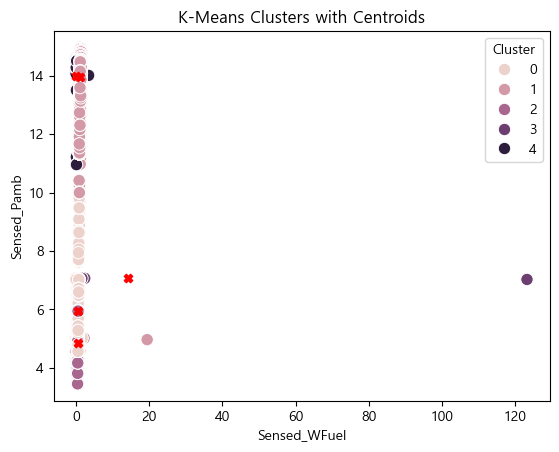

<Figure size 1000x1000 with 0 Axes>

In [19]:
# Sensed_WFuel vs Sensed_Pamb
sns.scatterplot(data=X, x='Sensed_WFuel', y='Sensed_Pamb', hue="Cluster", s=80)

plt.scatter(centroid_df['Sensed_WFuel'], centroid_df['Sensed_Pamb'], marker="X", label="Centroids", color="red")
plt.title('K-Means Clusters with Centroids')
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

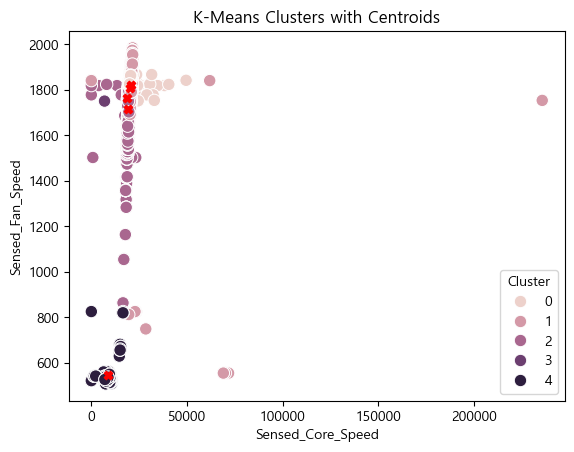

<Figure size 1000x1000 with 0 Axes>

In [20]:
# Sensed_Core_Speed vs Sensed_Fan_Speed
sns.scatterplot(data=X, x='Sensed_Core_Speed', y='Sensed_Fan_Speed', hue="Cluster", s=80)

plt.scatter(centroid_df['Sensed_Core_Speed'], centroid_df['Sensed_Fan_Speed'], marker="X", label="Centroids", color="red")
plt.title('K-Means Clusters with Centroids')
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

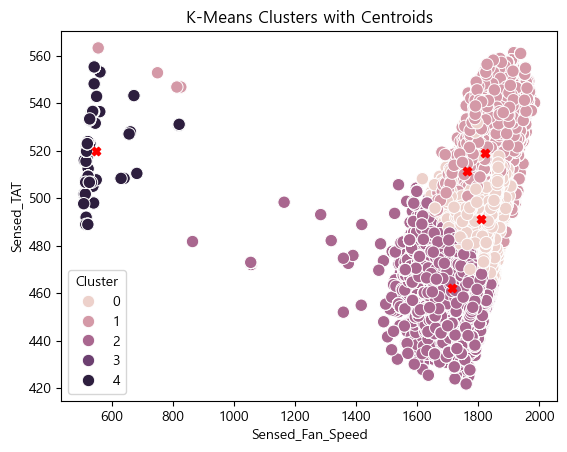

<Figure size 1000x1000 with 0 Axes>

In [21]:
# Sensed_Fan_Speed vs Sensed_TAT
sns.scatterplot(data=X, x='Sensed_Fan_Speed', y='Sensed_TAT', hue="Cluster", s=80)

plt.scatter(centroid_df['Sensed_Fan_Speed'], centroid_df['Sensed_TAT'], marker="X", label="Centroids", color="red")
plt.title('K-Means Clusters with Centroids')
plt.figure(figsize=(10, 10))

<Figure size 1000x1000 with 0 Axes>

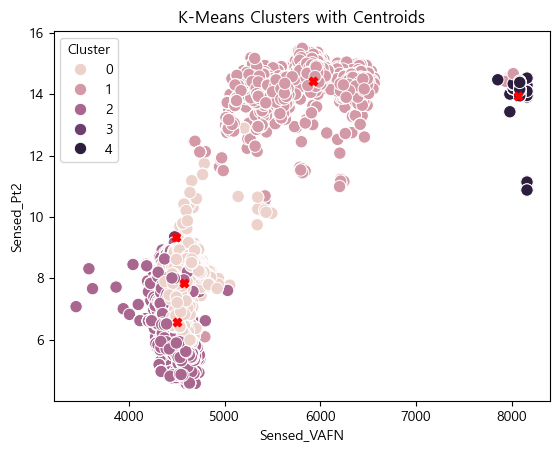

<Figure size 1000x1000 with 0 Axes>

In [22]:
# Sensed_VAFN vs Sensed_Pt2
sns.scatterplot(data=X, x='Sensed_VAFN', y='Sensed_Pt2', hue="Cluster", s=80)

plt.scatter(centroid_df['Sensed_VAFN'], centroid_df['Sensed_Pt2'], marker="X", label="Centroids", color="red")
plt.title('K-Means Clusters with Centroids')
plt.figure(figsize=(10, 10))

<Figure size 2000x2000 with 0 Axes>

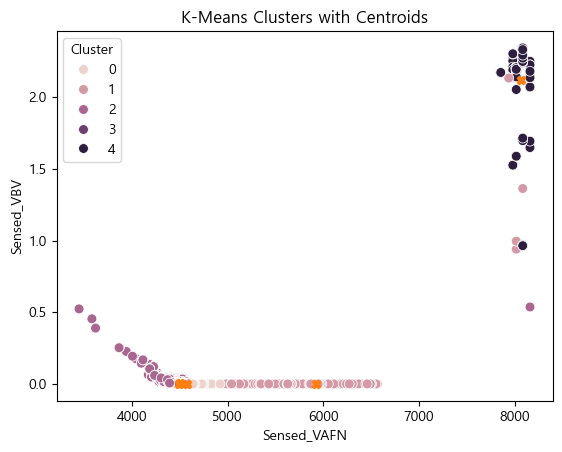

<Figure size 2000x2000 with 0 Axes>

In [23]:
# Sensed_VAFN vs Sensed_VBV
sns.scatterplot(data=X, x='Sensed_VAFN', y='Sensed_VBV', hue="Cluster", s=50)

plt.scatter(centroid_df['Sensed_VAFN'], centroid_df['Sensed_VBV'], marker="X", label="Centroids", edgecolors=None)
plt.title('K-Means Clusters with Centroids')
plt.figure(figsize=(20, 20))

## 새로운 데이터 판별 규칙

- 새로 들어온 데이터의 위치 좌표와, 각 클러스터의 중심점까지의 거리를 모두 구하고, 가장 짧은 거리의 클러스터 군집에 새로운 데이터를 포함
- 그 후, 그 군집의 IQR 지표를 이용해 정상/비정상 데이터 판단

In [24]:
feature_names = centroid_df.columns.unique()
feature_names

Index(['Sensed_WFuel', 'Sensed_Pamb', 'Sensed_VAFN', 'Sensed_Pt2',
       'Sensed_VBV', 'Sensed_Fan_Speed', 'Sensed_TAT', 'Sensed_Core_Speed',
       'Sensed_T25'],
      dtype='object')

In [25]:
data_val

,ESN,Cycles,Snapshot,Sensed_Altitude,Sensed_Mach,Sensed_Pamb,Sensed_Pt2,Sensed_TAT,Sensed_WFuel,Sensed_VAFN,Sensed_VBV,Sensed_Fan_Speed,Sensed_Core_Speed,Sensed_T25,Sensed_T3,Sensed_Ps3,Sensed_T45
0,107,0,1,220.101374,0.101318,14.636435,14.614082,548.355107,1.383620,6309.267802,0.0,1929.094470,21583.849933,772.837312,1662.825876,472.839632,2340.578699
1,107,0,2,258.101374,0.230594,14.617612,15.057738,551.740546,1.409376,5868.590392,0.0,1931.780397,21622.243513,778.129517,1668.110764,482.900785,2341.415538
2,107,0,3,2095.101374,0.290444,13.707636,14.430108,546.046171,1.270594,5642.323288,0.0,1884.167347,21384.973643,765.536788,1635.170989,444.779601,2283.432521
3,107,0,4,20694.101374,0.600026,6.600726,8.374084,502.748559,0.749673,4706.196925,0.0,1885.717793,20657.994841,723.683299,1537.943883,272.400642,2152.439536
4,107,0,5,30096.101374,0.712355,4.370061,6.097945,473.182038,0.554500,4574.230754,0.0,1866.862206,20123.708923,690.535650,1468.052512,205.521518,2068.133158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,107,1500,4,20573.101374,0.563486,6.632249,8.182092,505.415560,0.719114,4776.076045,0.0,1867.000982,20621.241453,726.475354,1535.179201,257.505900,2170.797390
1115,107,1500,5,28998.101374,0.644630,4.606091,6.058782,479.340661,0.525835,4638.036914,0.0,1831.572172,20089.001692,694.154437,1465.458690,192.147512,2085.260307
1116,107,1500,6,30000.101374,0.648410,4.387498,5.789550,475.400106,0.503381,4633.828899,0.0,1827.054084,20012.745467,689.316346,1455.671749,184.253397,2074.788211
1117,107,1500,7,29989.101374,0.704228,4.389680,6.080518,485.003552,0.513706,4541.005943,0.0,1827.689014,20143.598826,701.785732,1472.383713,188.278386,2087.236429


In [26]:
# 각 군집의 중심점 기준으로 IQR 범위 구하기
Q1 = X.groupby('Cluster')[feature_names].quantile(0.25)
Q3 = X.groupby('Cluster')[feature_names].quantile(0.75)
IQR = Q3 - Q1

Lower = Q1-1.5*IQR
Upper = Q3+1.5*IQR

cluster_IQR_df = Lower.add_suffix('_lower').join((Upper).add_suffix('_upper'))
cluster_IQR_df

,Sensed_WFuel_lower,Sensed_Pamb_lower,Sensed_VAFN_lower,Sensed_Pt2_lower,Sensed_VBV_lower,Sensed_Fan_Speed_lower,Sensed_TAT_lower,Sensed_Core_Speed_lower,Sensed_T25_lower,Sensed_WFuel_upper,Sensed_Pamb_upper,Sensed_VAFN_upper,Sensed_Pt2_upper,Sensed_VBV_upper,Sensed_Fan_Speed_upper,Sensed_TAT_upper,Sensed_Core_Speed_upper,Sensed_T25_upper
Cluster,,,,,,,,,,,,,,,,,,
0,0.284614,2.605348,4264.517084,4.735192,0.000000,1678.492347,452.251322,19300.481063,646.242015,0.949538,9.029099,4866.212121,10.823813,0.000000,1952.781819,529.884153,20983.963500,745.672587
1,0.948358,11.956257,4570.068197,13.531114,0.000000,1647.074969,458.586110,19475.163096,628.126535,1.429061,15.874050,7288.888528,15.448377,0.000000,2008.163250,581.875386,22055.800454,814.561862
2,0.355819,2.615473,4222.752067,4.089904,-0.008230,1498.933634,422.813709,18631.889951,595.690995,0.589331,6.802394,4776.323101,8.856088,0.013716,1940.030403,500.997491,20206.663318,704.812404
3,-2.006370,7.061115,4477.252484,9.349292,0.002794,1750.840702,510.641532,15663.847250,27324.038861,3.770975,7.061115,4477.252484,9.349292,0.002794,1750.840702,510.641532,24134.265813,28303.100981
4,-0.169825,13.447891,7802.232979,13.303314,2.020258,482.025862,471.474244,3564.779883,493.563158,0.283042,15.143994,8377.350271,15.172575,2.387713,575.145340,569.819537,14457.495592,601.912569


In [27]:
# validation 데이터셋을 순회하며 각 컬럼의 IQR 값을 비교하여 정상/비정상 상태 판단
# 1: 정상 / 0: 비정상
df_data = data_val[features_names]
df_data['judge'] = 1
for i in range(len(df_data)):
    for f_name in features_names:
        lower = centroid_IQR_df.loc[0,f_name]
        highest = centroid_IQR_df.loc[1,f_name]
        value = df_data.loc[i,f_name]
        if lower > value or value > highest:
            df_data.loc[i,'judge'] = 0
            break

# data_val
# df_data
df_data_zero = df_data[df_data['judge'] == 0].drop(['judge'],axis=1)
df_data_zero
# df_data['judge'].unique()

C:\Users\cyj01\AppData\Local\Temp\ipykernel_11504\3947052116.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data['judge'] = 1


NameError: name 'centroid_IQR_df' is not defined